# Customer Churn Project

In [1]:
# Run once to install libraries
!pip install lifelines scikit-survival xgboost lightgbm --quiet
!pip install scikeras --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 13.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from tensorflow.keras.callbacks import EarlyStopping

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

## Data loading and cleaning

In [3]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic cleaning
df.columns = [c.strip() for c in df.columns]
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Fill missing TotalCharges
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop customerID due to irrelevant
df.drop(columns=['customerID'], inplace=True)

# Remove exact duplicates if any
df.drop_duplicates().reset_index(drop=True)

print(f"Churn rate: {df['Churn'].mean():.1%}")
print(df.describe())
df.head()

Churn rate: 26.5%
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges        Churn
count    7043.000000  7043.000000     7043.000000   7043.000000  7043.000000
mean        0.162147    32.371149       64.761692   2281.916928     0.265370
std         0.368612    24.559481       30.090047   2265.270398     0.441561
min         0.000000     0.000000       18.250000     18.800000     0.000000
25%         0.000000     9.000000       35.500000    402.225000     0.000000
50%         0.000000    29.000000       70.350000   1397.475000     0.000000
75%         0.000000    55.000000       89.850000   3786.600000     1.000000
max         1.000000    72.000000      118.750000   8684.800000     1.000000


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# EDA

In [4]:
# Univariate — numeric features only
print("Univariate Descriptive Statistics")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

Univariate Descriptive Statistics
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2281.92
std      24.56           30.09       2265.27
min       0.00           18.25         18.80
25%       9.00           35.50        402.22
50%      29.00           70.35       1397.48
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


In [5]:
# Bivariate — split by churn
print("Key Features by Churn Status")
print(df.groupby('Churn')[['tenure', 'MonthlyCharges']]
      .agg(['mean', 'median', 'std']).round(2))

Key Features by Churn Status
      tenure               MonthlyCharges              
        mean median    std           mean median    std
Churn                                                  
0      37.57   38.0  24.11          61.27  64.43  31.09
1      17.98   10.0  19.53          74.44  79.65  24.67


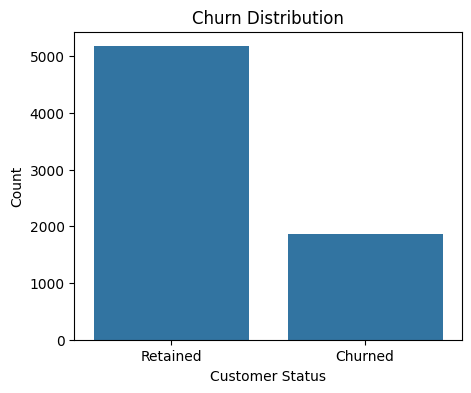

In [6]:
# Churn distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Churn')
xticklabels = ['Retained', 'Churned']
plt.title('Churn Distribution')
plt.xlabel("Customer Status")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=xticklabels)
plt.show()

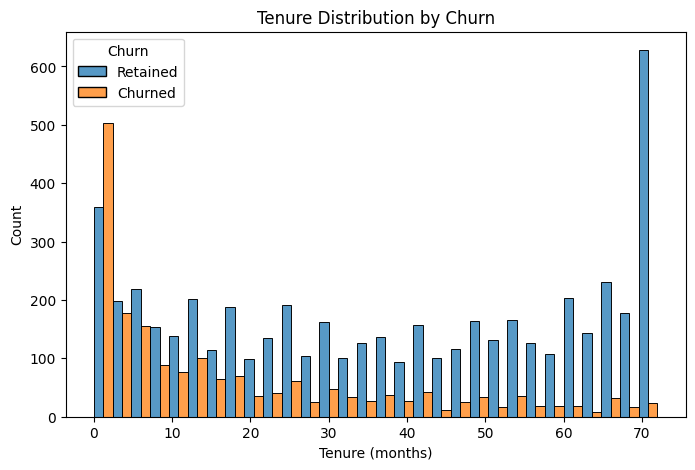

In [7]:
# TENURE
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure',
             hue=df['Churn'].map({0: 'Retained', 1: 'Churned'}),
             bins=30, multiple='dodge', kde=False)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.show()

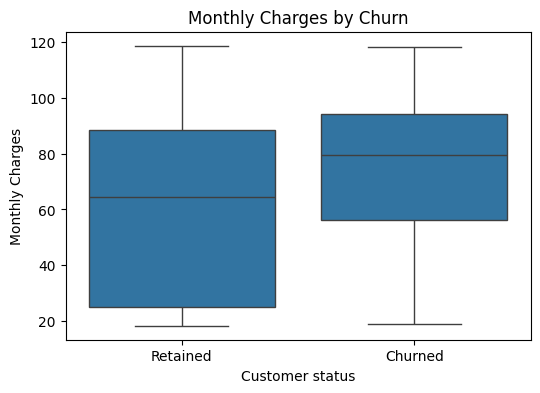

In [8]:
# MONTHLY CHARGES
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
xticklabels = ['Retained', 'Churned']
plt.title('Monthly Charges by Churn')
plt.xlabel('Customer status')
plt.ylabel('Monthly Charges')
plt.xticks(ticks=[0, 1], labels=xticklabels)
plt.show()

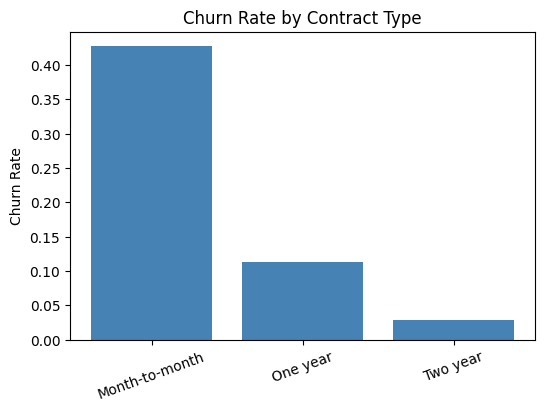

In [9]:
# CONTRACT TYPE
plt.figure(figsize=(6, 4))
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
plt.bar(contract_churn.index, contract_churn.values, color='steelblue')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=20)
plt.show()


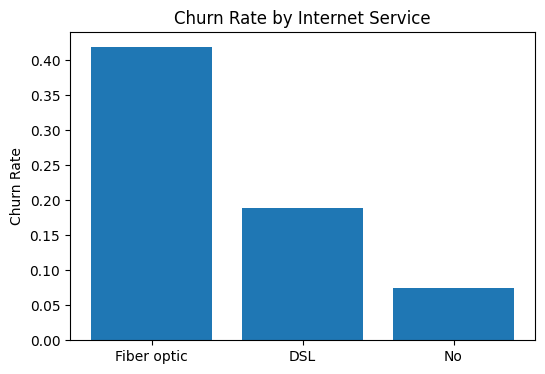

In [10]:
# INTERNET SERVICE
plt.figure(figsize=(6, 4))
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
plt.bar(internet_churn.index, internet_churn.values)
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate')
plt.show()

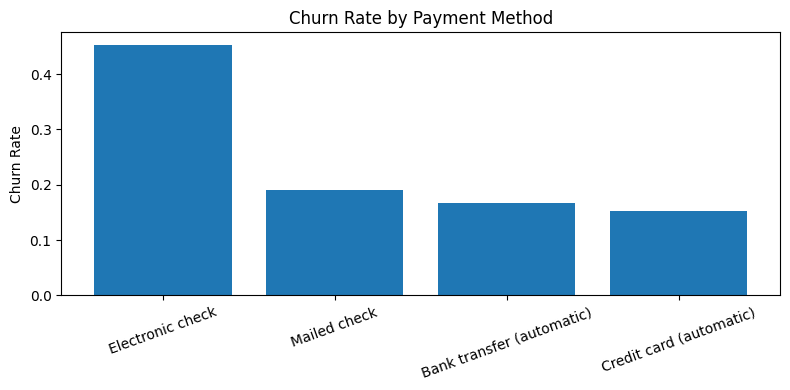

In [11]:
# PAYMENT METHOD
plt.figure(figsize=(8, 4))
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
plt.bar(payment_churn.index, payment_churn.values)
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

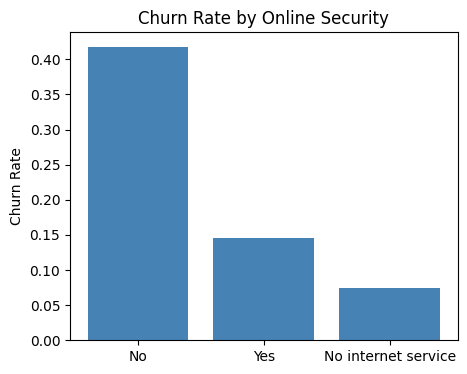

In [12]:
# Online Security
plt.figure(figsize=(5, 4))
churn_rate = df.groupby('OnlineSecurity')['Churn'].mean().sort_values(ascending=False)
plt.bar(churn_rate.index, churn_rate.values, color='steelblue')
plt.title('Churn Rate by Online Security')
plt.ylabel('Churn Rate')
plt.show()

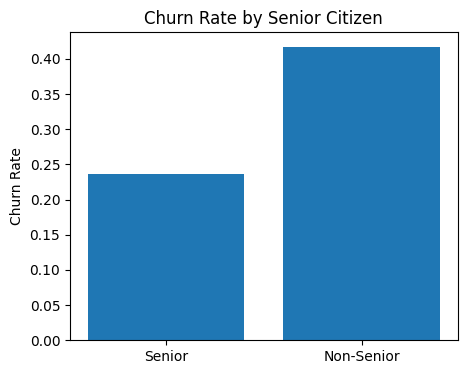

In [13]:
# SENIOR CITIZEN
plt.figure(figsize=(5, 4))
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean()
senior_churn.index = senior_churn.index.map({0: 'Non-Senior', 1: 'Senior'})
plt.bar(['Senior', 'Non-Senior'], senior_churn.values)
plt.title('Churn Rate by Senior Citizen')
plt.ylabel('Churn Rate')
plt.show()

In [14]:
# FEATURE DEFINITION & SPLIT
# Define categorical features for future preprocessing
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
num_cols = ['MonthlyCharges']

# Dropped 'tenure', 'Churn' to prevent data leakage and 'TotalCharges' to avoid multicollinearity
X = df.drop(columns=['tenure', 'Churn', 'TotalCharges'])

# 't' represents the duration/time to event (how long the customer stayed)
t = df['tenure'].astype(float)

## 'e' acts as the event indicator (True if the customer actually churned, False if retained)
e = df['Churn'].astype(bool)

In [15]:
# 60 / 20 / 20 split - index-based to keep X, t, e aligned
# Use index-based splitting to ensure strict alignment between X (features),
idx = np.arange(len(df))
idx_temp, idx_test = train_test_split(idx, test_size=0.20, random_state=42, stratify=e)
idx_train, idx_val  = train_test_split(idx_temp, test_size=0.25, random_state=42,
                                        stratify=e.iloc[idx_temp])

X_train, X_val, X_test = X.iloc[idx_train], X.iloc[idx_val], X.iloc[idx_test]
t_train, t_val, t_test = t.iloc[idx_train], t.iloc[idx_val], t.iloc[idx_test]
e_train, e_val, e_test = e.iloc[idx_train], e.iloc[idx_val], e.iloc[idx_test]

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")



Train: 4225, Val: 1409, Test: 1409


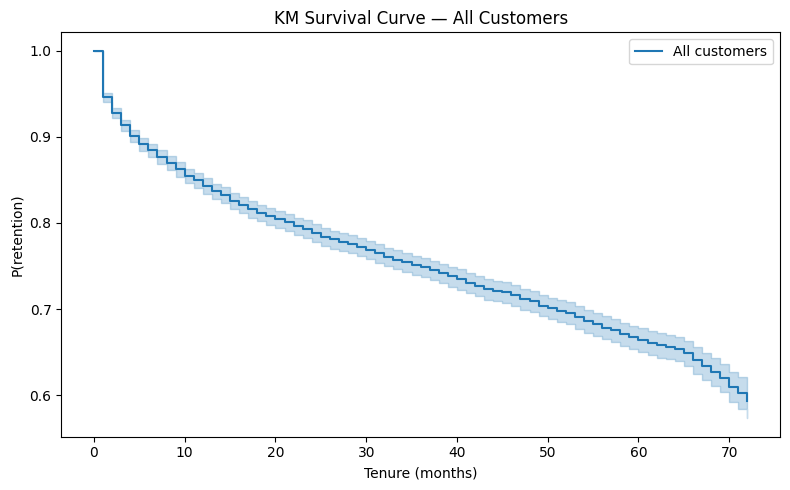

In [16]:
# Kaplan-Meier
plt.figure(figsize=(8, 5))
kmf = KaplanMeierFitter()
kmf.fit(t, e, label='All customers')
kmf.plot_survival_function(ci_show=True)
plt.title('KM Survival Curve — All Customers')
plt.xlabel('Tenure (months)')
plt.ylabel('P(retention)')
plt.tight_layout()
plt.show()

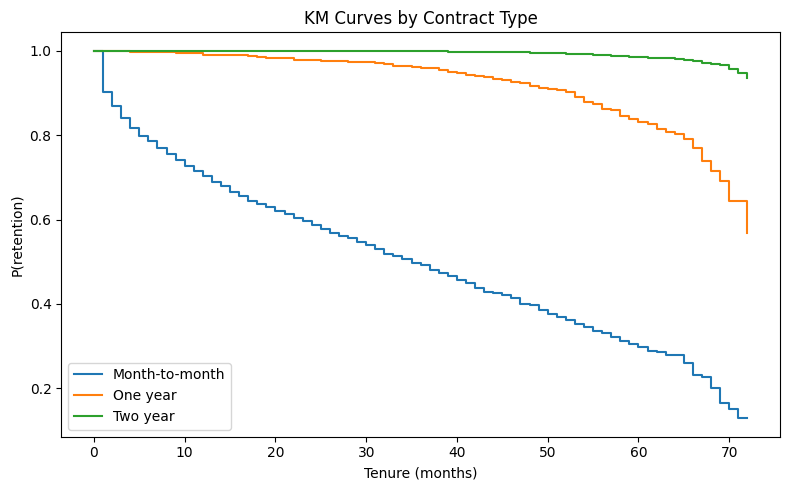

In [17]:
# KM by Contract Type
plt.figure(figsize=(8, 5))
kmf_groups = {}
for contract in ['Month-to-month', 'One year', 'Two year']:
    mask = df['Contract'] == contract
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(t[mask], e[mask], label=contract)
    kmf_g.plot_survival_function(ci_show=False)
    kmf_groups[contract] = (t[mask], e[mask])

plt.title('KM Curves by Contract Type')
plt.xlabel('Tenure (months)')
plt.ylabel('P(retention)')
plt.tight_layout()
plt.show()

In [18]:
# Log-rank test
lr_result = logrank_test(
    kmf_groups['Month-to-month'][0], kmf_groups['Two year'][0],
    kmf_groups['Month-to-month'][1], kmf_groups['Two year'][1]
)
print(f"Log-rank test (Month-to-month vs Two year): p = {lr_result.p_value:.2e}")

Log-rank test (Month-to-month vs Two year): p = 0.00e+00


In [19]:
# PREPROCESSING PIPELINE
preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols),
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler())
    ]), num_cols)
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)
feat_names = preprocessor.get_feature_names_out()

print(f"Encoded feature matrix: {X_train_p.shape}")

Encoded feature matrix: (4225, 44)


# CLASSIFICATION

In [20]:
# Define targets
y_train_ann = e_train.astype(int).values
y_val_ann   = e_val.astype(int).values
y_test_ann  = e_test.astype(int).values
y_train_cls = e_train.astype(int).values
y_val_cls = e_val.astype(int).values
y_test_cls = e_test.astype(int).values

# Logistic Regression
lr_params = {
    'C': loguniform(0.01, 10),
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=lr_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
lr_search.fit(X_train_p, y_train_ann)

print("Best LR params:", lr_search.best_params_)
print(f"Best LR CV AUC: {lr_search.best_score_:.4f}")

# Best model
lr = lr_search.best_estimator_

Best LR params: {'C': np.float64(0.13292918943162169), 'max_iter': 500, 'solver': 'lbfgs'}
Best LR CV AUC: 0.8346


In [21]:
# Random forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train_p, y_train_cls)

print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV AUC: {rf_search.best_score_:.4f}")

# Best model
rf = rf_search.best_estimator_

Best RF params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 10}
Best RF CV AUC: 0.8318


In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score
import itertools
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights for imbalanced datasets
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_cls),
    y=y_train_cls
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

#ANN
# Search space
param_grid = {
    'neurons_1':     [64, 128],
    'neurons_2':     [32, 64],
    'dropout_1':     [0.2, 0.3],
    'dropout_2':     [0.1, 0.2],
    'learning_rate': [0.001, 0.005],
    'batch_size':    [32, 64]
}

# Generate all combinations and then sample 15
import random
random.seed(42)
keys   = list(param_grid.keys())
values = list(param_grid.values())
all_combinations = list(itertools.product(*values))
sampled = random.sample(all_combinations, 15)

best_val_auc = 0
best_params  = None

for combo in sampled:
    params = dict(zip(keys, combo))

    tf.random.set_seed(42)
    model = keras.Sequential([
        layers.Input(shape=(X_train_p.shape[1],)),
        layers.Dense(params['neurons_1'], activation='relu'),
        layers.Dropout(params['dropout_1']),
        layers.Dense(params['neurons_2'], activation='relu'),
        layers.Dropout(params['dropout_2']),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(params['learning_rate']),
        loss='binary_crossentropy',
        metrics=['AUC']
    )

    model.fit(
        X_train_p, y_train_cls,
        validation_data=(X_val_p, y_val_cls),
        epochs=50,
        batch_size=params['batch_size'],
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_AUC', patience=5,
                                  restore_best_weights=True, mode='max')],
        verbose=0
    )

    val_auc = roc_auc_score(y_val_cls,
                             model.predict(X_val_p, verbose=0).flatten())

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_params  = params

print("Best params:", best_params)
print(f"Best val AUC: {best_val_auc:.4f}")

Best params: {'neurons_1': 64, 'neurons_2': 32, 'dropout_1': 0.2, 'dropout_2': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
Best val AUC: 0.8198


In [23]:
# Final ANN
tf.random.set_seed(42)
ann = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(best_params['neurons_1'], activation='relu'),
    layers.Dropout(best_params['dropout_1']),
    layers.Dense(best_params['neurons_2'], activation='relu'),
    layers.Dropout(best_params['dropout_2']),
    layers.Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['AUC']
)

early_stop = EarlyStopping(
    monitor='val_AUC',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

history = ann.fit(
    X_train_p, y_train_cls,
    validation_data=(X_val_p, y_val_cls),
    epochs=100,
    batch_size=best_params['batch_size'],
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=0
)

print(f"Best params: {best_params}")
print(f"Stopped at epoch: {early_stop.stopped_epoch + 1}")
ann.summary()

Best params: {'neurons_1': 64, 'neurons_2': 32, 'dropout_1': 0.2, 'dropout_2': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
Stopped at epoch: 13


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 64)             │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,981 (58.52 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,988 (39.02 KB)

In [24]:
# Evaluate on all three sets
def ann_auc(X, y):
    prob = ann.predict(X, verbose=0).flatten()
    return roc_auc_score(y, prob)

auc_train = ann_auc(X_train_p, y_train_ann)
auc_val   = ann_auc(X_val_p,   y_val_ann)
auc_test  = ann_auc(X_test_p,  y_test_ann)

print(f"ANN | Train AUC: {auc_train:.4f} | Val AUC: {auc_val:.4f} | Test AUC: {auc_test:.4f}")

ANN | Train AUC: 0.8402 | Val AUC: 0.8184 | Test AUC: 0.8158


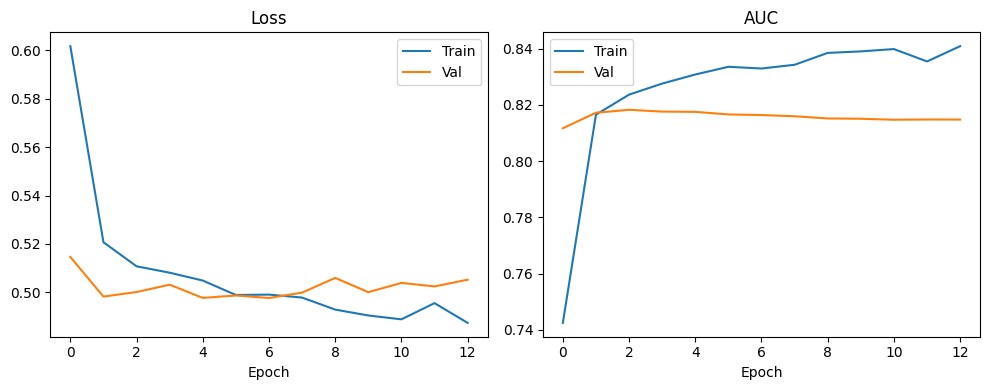

In [25]:
# Training curve
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['AUC'], label='Train')
plt.plot(history.history['val_AUC'], label='Val')
plt.title('AUC')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

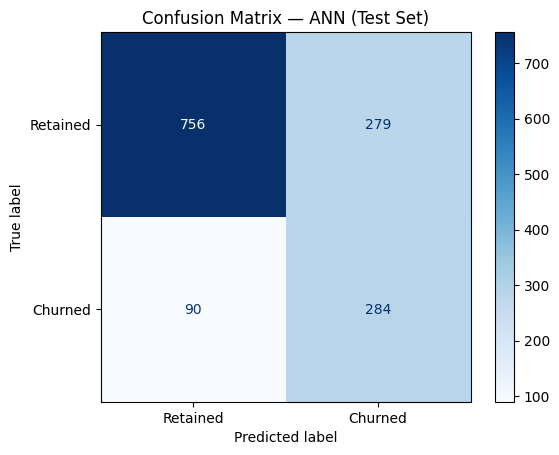

In [26]:
# Confusion Matrix
y_pred_ann = (ann.predict(X_test_p, verbose=0).flatten() >= 0.5).astype(int)
cm = confusion_matrix(y_test_ann, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — ANN (Test Set)')
plt.show()

In [27]:
# Predictions from 3 models
lr_pred  = lr.predict(X_test_p)
rf_pred  = rf.predict(X_test_p)
ann_pred = y_pred_ann
rows = []
for name, pred in [('Logistic Regression', lr_pred),
                    ('Random Forest',       rf_pred),
                    ('ANN (Keras)',          ann_pred)]:
    report = classification_report(y_test_ann, pred,
                                   target_names=['Retained', 'Churned'],
                                   output_dict=True)
    rows.append({
        'Model':                name,
        'Precision (Churned)':  round(report['Churned']['precision'], 3),
        'Recall (Churned)':     round(report['Churned']['recall'],    3),
        'F1 (Churned)':         round(report['Churned']['f1-score'],  3),
        'Accuracy':             round(report['accuracy'],             3),
    })

summary = pd.DataFrame(rows)
print("Table: Classification Report Comparison (Test Set)")
print(summary.to_string(index=False))

Table: Classification Report Comparison (Test Set)
              Model  Precision (Churned)  Recall (Churned)  F1 (Churned)  Accuracy
Logistic Regression                0.594             0.508         0.548     0.777
      Random Forest                0.599             0.463         0.522     0.775
        ANN (Keras)                0.504             0.759         0.606     0.738


In [28]:
results_cls = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'ANN (Keras)'],
    'Train AUC': [
        roc_auc_score(y_train_cls, lr.predict_proba(X_train_p)[:,1]),
        roc_auc_score(y_train_cls, rf.predict_proba(X_train_p)[:,1]),
        auc_train
    ],
    'Val AUC': [
        roc_auc_score(y_val_cls, lr.predict_proba(X_val_p)[:,1]),
        roc_auc_score(y_val_cls, rf.predict_proba(X_val_p)[:,1]),
        auc_val
    ],
    'Test AUC': [
        roc_auc_score(y_test_cls, lr.predict_proba(X_test_p)[:,1]),
        roc_auc_score(y_test_cls, rf.predict_proba(X_test_p)[:,1]),
        auc_test
    ]
}).round(4)

print("Classification Model Comparison (AUC-ROC)")
print(results_cls.to_string(index=False))

Classification Model Comparison (AUC-ROC)
              Model  Train AUC  Val AUC  Test AUC
Logistic Regression     0.8396   0.8200    0.8184
      Random Forest     0.8723   0.8178    0.8192
        ANN (Keras)     0.8402   0.8184    0.8158


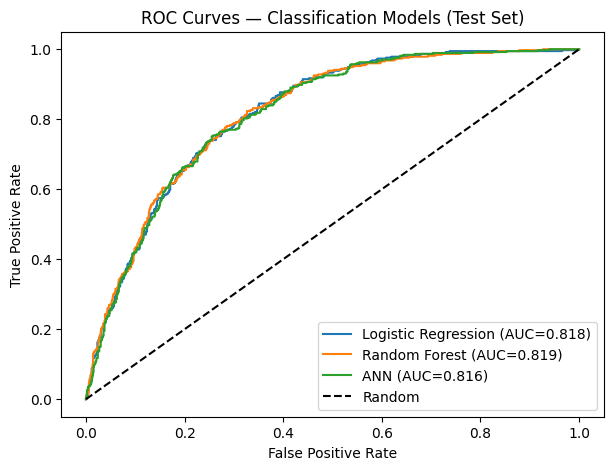

In [29]:
plt.figure(figsize=(7, 5))

for name, clf in [('Logistic Regression', lr), ('Random Forest', rf)]:
    fpr, tpr, _ = roc_curve(y_test_cls, clf.predict_proba(X_test_p)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})')

fpr, tpr, _ = roc_curve(y_test_cls,
                          ann.predict(X_test_p, verbose=0).flatten())
plt.plot(fpr, tpr, label=f'ANN (AUC={auc(fpr,tpr):.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Classification Models (Test Set)')
plt.legend()
plt.show()

# SURVIVAL ANALYSIS

In [30]:
# SURVIVAL TARGET ARRAYS
def make_surv_array(event, time):
    """Structured array format required by scikit-survival."""
    return np.array(
        list(zip(event.values, time.values)),
        dtype=[('churn', bool), ('tenure', float)]
    )

y_train_s = make_surv_array(e_train, t_train)
y_val_s = make_surv_array(e_val, t_val)
y_test_s = make_surv_array(e_test, t_test)

In [31]:
def make_cox_df(X_p, t, e):
    df_cox = pd.DataFrame(X_p, columns=feat_names)
    df_cox['tenure'] = t.values
    df_cox['Churn'] = e.astype(int).values # Ensure 'Churn' is integer (0/1)
    return df_cox

# COX PH
penalizer_results = []

for penalizer in [0.01, 0.05, 0.1, 0.5, 1.0]:
    cph_temp = CoxPHFitter(penalizer=penalizer)
    cph_temp.fit(make_cox_df(X_train_p, t_train, e_train),
                 duration_col='tenure', event_col='Churn')
    score = cph_temp.score(make_cox_df(X_val_p, t_val, e_val),
                           scoring_method='concordance_index')
    penalizer_results.append({'penalizer': penalizer, 'val_C_index': round(score, 4)})

cox_search = pd.DataFrame(penalizer_results)
best_penalizer = cox_search.loc[cox_search['val_C_index'].idxmax(), 'penalizer']

print("Cox PH Penalizer Search:")
print(cox_search.to_string(index=False))
print(f" Selected: penalizer = {best_penalizer}")

# Final Cox
cph = CoxPHFitter(penalizer=best_penalizer)
cph.fit(make_cox_df(X_train_p, t_train, e_train),
        duration_col='tenure', event_col='Churn')

c_cox_train = cph.score(make_cox_df(X_train_p, t_train, e_train),
                         scoring_method='concordance_index')
c_cox_val   = cph.score(make_cox_df(X_val_p, t_val, e_val),
                         scoring_method='concordance_index')
c_cox_test  = cph.score(make_cox_df(X_test_p, t_test, e_test),
                         scoring_method='concordance_index')

print(f"\nCox PH | Train: {c_cox_train:.4f} | Val: {c_cox_val:.4f} | Test: {c_cox_test:.4f}")

Cox PH Penalizer Search:
 penalizer  val_C_index
      0.01       0.8591
      0.05       0.8576
      0.10       0.8558
      0.50       0.8471
      1.00       0.8418
 Selected: penalizer = 0.01

Cox PH | Train: 0.8712 | Val: 0.8591 | Test: 0.8554


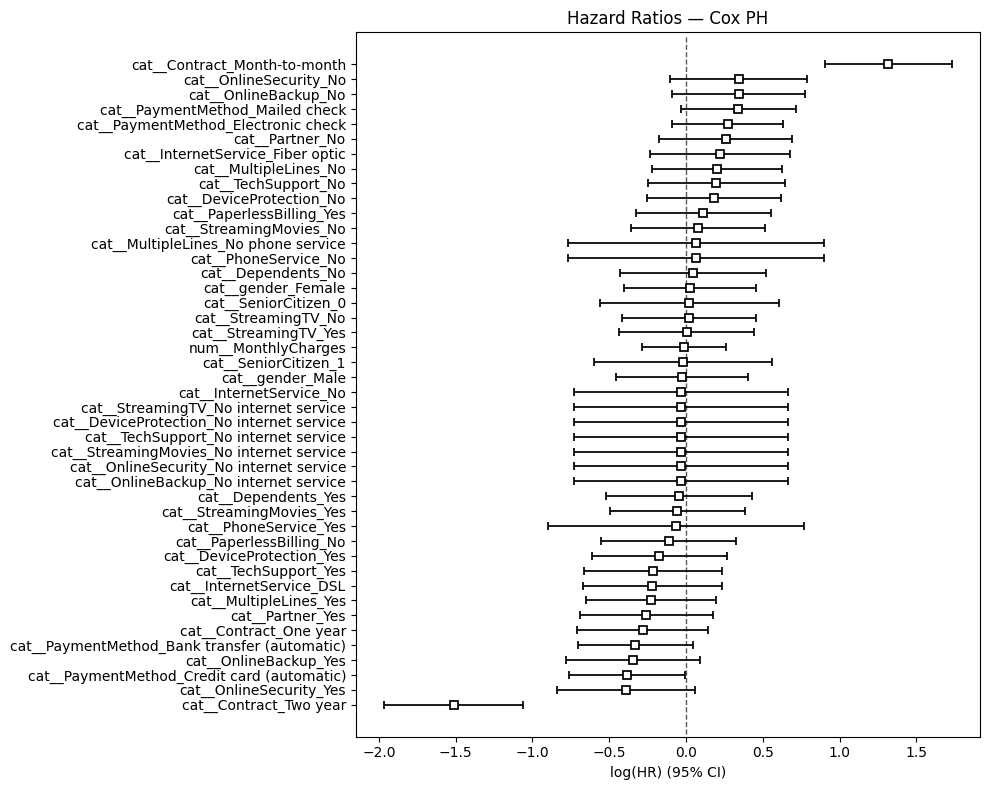

In [32]:
# Hazard ratio plot
plt.figure(figsize=(10, 8))
cph.plot()
plt.title('Hazard Ratios — Cox PH')
plt.tight_layout()
plt.savefig('cox_hazard_ratios.png', dpi=150)
plt.show()

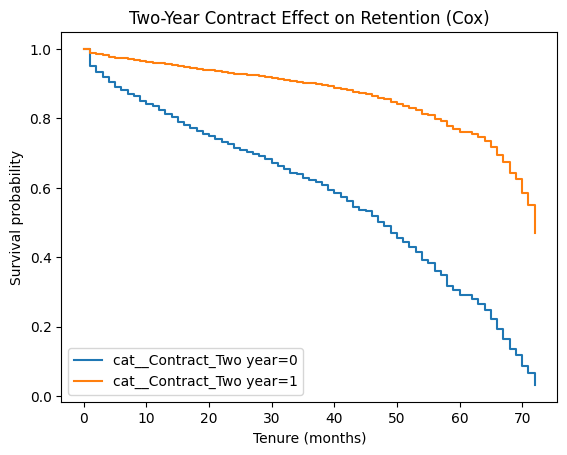

In [33]:
# Partial effect: contract type
cph.plot_partial_effects_on_outcome(
    covariates='cat__Contract_Two year', values=[0, 1], plot_baseline=False
)
plt.title('Two-Year Contract Effect on Retention (Cox)')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival probability')
plt.savefig('cox_contract_effect.png', dpi=150)
plt.show()

In [34]:
# RANDOM SURVIVAL FOREST
rsf_results = []

for leaf in [10, 15, 20, 30]:
    for n_trees in [100, 200, 300]:
        rsf_temp = RandomSurvivalForest(
            n_estimators=n_trees,
            min_samples_leaf=leaf,
            max_features='sqrt',
            n_jobs=-1,
            random_state=42
        )
        rsf_temp.fit(X_train_p, y_train_s)
        score = rsf_temp.score(X_val_p, y_val_s)
        rsf_results.append({
            'n_estimators':      n_trees,
            'min_samples_leaf':  leaf,
            'val_C_index':       round(score, 4)
        })

rsf_search = pd.DataFrame(rsf_results)
best_rsf = rsf_search.loc[rsf_search['val_C_index'].idxmax()]
print(rsf_search.to_string(index=False))
print(f"\nSelected: n_estimators={int(best_rsf['n_estimators'])}, "
      f"min_samples_leaf={int(best_rsf['min_samples_leaf'])}")

best_n_trees = int(best_rsf['n_estimators'])
best_leaf = int(best_rsf['min_samples_leaf'])

# Final RSF
rsf = RandomSurvivalForest(
    n_estimators=best_n_trees,
    min_samples_leaf=best_leaf,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rsf.fit(X_train_p, y_train_s)

c_rsf_train = rsf.score(X_train_p, y_train_s)
c_rsf_val   = rsf.score(X_val_p,   y_val_s)
c_rsf_test  = rsf.score(X_test_p,  y_test_s)

print(f"\nRSF | Train: {c_rsf_train:.4f} | Val: {c_rsf_val:.4f} | Test: {c_rsf_test:.4f}")

 n_estimators  min_samples_leaf  val_C_index
          100                10       0.8386
          200                10       0.8401
          300                10       0.8404
          100                15       0.8415
          200                15       0.8414
          300                15       0.8421
          100                20       0.8452
          200                20       0.8442
          300                20       0.8444
          100                30       0.8450
          200                30       0.8455
          300                30       0.8453

Selected: n_estimators=200, min_samples_leaf=30

RSF | Train: 0.8664 | Val: 0.8455 | Test: 0.8430


In [35]:
# GRADIENT BOOSTING SURVIVAL
gbs_results = []

for lr_val in [0.05, 0.1, 0.15]:
    for depth in [3, 4, 5]:
          gbs_temp = GradientBoostingSurvivalAnalysis(
              n_estimators=200,
              learning_rate=lr_val,
              max_depth=depth,
              subsample=0.8,
              min_samples_leaf=10,
              random_state=42
            )
          gbs_temp.fit(X_train_p, y_train_s)
          score = gbs_temp.score(X_val_p, y_val_s)
          gbs_results.append({
              'learning_rate': lr_val,
              'max_depth':     depth,
              'subsample':     0.8,
              'val_C_index':   round(score, 4)
            })

gbs_search = pd.DataFrame(gbs_results)
best_gbs_row = gbs_search.loc[gbs_search['val_C_index'].idxmax()]
best_lr      = best_gbs_row['learning_rate']
best_depth   = int(best_gbs_row['max_depth'])

print("GBS Search Results:")
print(gbs_search.to_string(index=False))
print(f"\n Selected: learning_rate={best_lr}, max_depth={best_depth}")

# Final GBS
gbs = GradientBoostingSurvivalAnalysis(
    n_estimators=200,
    learning_rate=best_lr,
    max_depth=best_depth,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)
gbs.fit(X_train_p, y_train_s)

c_gbs_train = gbs.score(X_train_p, y_train_s)
c_gbs_val   = gbs.score(X_val_p,   y_val_s)
c_gbs_test  = gbs.score(X_test_p,  y_test_s)

print(f"\nGBS | Train: {c_gbs_train:.4f} | Val: {c_gbs_val:.4f} | Test: {c_gbs_test:.4f}")

GBS Search Results:
 learning_rate  max_depth  subsample  val_C_index
          0.05          3        0.8       0.8546
          0.05          4        0.8       0.8558
          0.05          5        0.8       0.8535
          0.10          3        0.8       0.8581
          0.10          4        0.8       0.8567
          0.10          5        0.8       0.8530
          0.15          3        0.8       0.8586
          0.15          4        0.8       0.8552
          0.15          5        0.8       0.8504

 Selected: learning_rate=0.15, max_depth=3

GBS | Train: 0.8819 | Val: 0.8586 | Test: 0.8566


In [36]:
# Comparison between survival models
comparison = pd.DataFrame({
    'Model':          ['Cox PH (penalized)', 'Random Survival Forest', 'Gradient Boosting Survival'],
    'C-index (train)': [c_cox_train, c_rsf_train, c_gbs_train],
    'C-index (val)':   [c_cox_val,   c_rsf_val,   c_gbs_val],
    'C-index (test)':  [c_cox_test,  c_rsf_test,  c_gbs_test],
}).round(4).sort_values('C-index (val)', ascending=False).reset_index(drop=True)

print("\nSurvival Model Comparison — C-index across splits")
print(comparison.to_string(index=False))


Survival Model Comparison — C-index across splits
                     Model  C-index (train)  C-index (val)  C-index (test)
        Cox PH (penalized)           0.8712         0.8591          0.8554
Gradient Boosting Survival           0.8819         0.8586          0.8566
    Random Survival Forest           0.8664         0.8455          0.8430


# Business Application

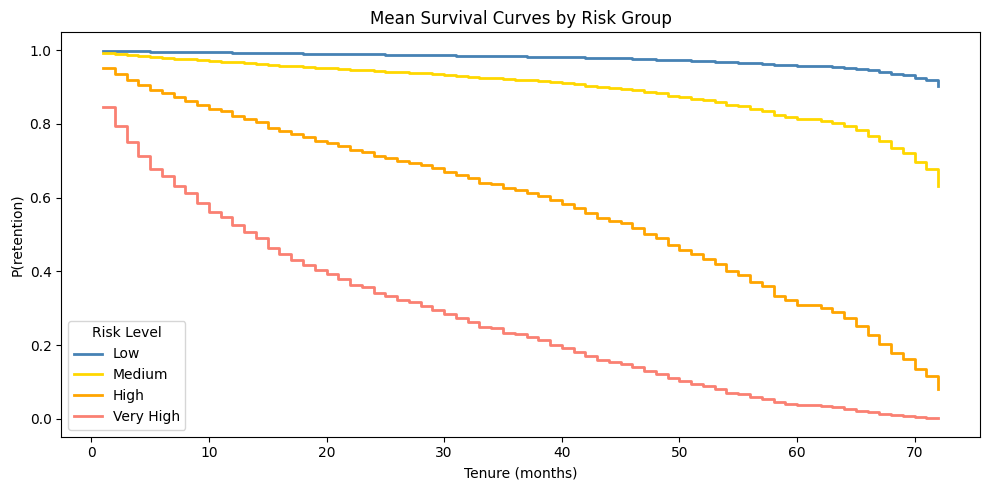

In [37]:
# Label customers based on risk level
prediction_model = gbs
risk_scores = prediction_model.predict(X_test_p)   # use test set for final business output

risk_df = pd.DataFrame({
    'Risk_Score':   risk_scores,
    'Tenure':       t_test.values,
    'Contract':     X_test['Contract'].values,
    'Actual_Churn': e_test.values
})
# Risk level are rank according to Risk score
#     Bottom 25%: Low
#     25-50%    : Medium
#     50-75%    : High
#     Top 25%   : Very High
risk_df['Risk_Level'] = pd.qcut(
    risk_df['Risk_Score'], q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Survival curves for each risk group
plt.figure(figsize=(10, 5))
colors = {'Low': 'steelblue', 'Medium': 'gold', 'High': 'orange', 'Very High': 'salmon'}
times = np.arange(1, int(t_test.max()) + 1)

for level in ['Low', 'Medium', 'High', 'Very High']:
    mask = (risk_df['Risk_Level'] == level).values
    funcs = prediction_model.predict_survival_function(X_test_p[mask])
    mean_surv = np.mean([fn(times) for fn in funcs], axis=0)
    plt.step(times, mean_surv, where='post', label=level,
             color=colors[level], lw=2)

plt.xlabel('Tenure (months)')
plt.ylabel('P(retention)')
plt.title('Mean Survival Curves by Risk Group')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.savefig('risk_group_survival.png', dpi=150)
plt.show()

In [38]:
# Risk over time - When to intervene:

# Flag top 10% risk
threshold = risk_df['Risk_Score'].quantile(0.90)
red_flags = risk_df[risk_df['Risk_Score'] >= threshold].copy()

idx_red = np.where(risk_df['Risk_Score'] >= threshold)[0]
red_flags['Churn_Prob_12m'] = [
    round(1 - fn(12), 3)
    for fn in prediction_model.predict_survival_function(X_test_p[idx_red])
]

print("\nTop 10 highest-risk customers:")
print(red_flags.sort_values('Risk_Score', ascending=False)
               [['Tenure', 'Contract', 'Risk_Score', 'Churn_Prob_12m', 'Actual_Churn']]
               .head(10).to_string())


Top 10 highest-risk customers:
      Tenure        Contract  Risk_Score  Churn_Prob_12m  Actual_Churn
997     13.0  Month-to-month    3.469062           0.883          True
987      4.0  Month-to-month    3.177890           0.798          True
171      1.0  Month-to-month    3.158019           0.792          True
898      3.0  Month-to-month    3.023754           0.746         False
1366     1.0  Month-to-month    3.023754           0.746          True
555      2.0  Month-to-month    3.003883           0.740         False
341      1.0  Month-to-month    3.003883           0.740          True
101     10.0  Month-to-month    3.003883           0.740          True
629      1.0  Month-to-month    3.003883           0.740         False
1252     1.0  Month-to-month    3.003883           0.740          True


In [39]:
# Note
# Revenue estimates based on test set results (n=1,409)
# Retention rate assumptions are indicative

# Baseline metrics
overall_churn_rate  = e_test.mean()
avg_monthly_charges = df['MonthlyCharges'].mean()
clv_annual          = avg_monthly_charges * 12

# Predict survival functions for all test customers
all_surv_funcs = prediction_model.predict_survival_function(X_test_p)

# Build risk dataframe with 12-month churn probability
risk_df_full = pd.DataFrame({
    'Risk_Score':     prediction_model.predict(X_test_p),
    'Tenure':         t_test.values,
    'Contract':       X_test['Contract'].values,
    'Actual_Churn':   e_test.values,
    'Churn_Prob_12m': [round(1 - fn(12), 3) for fn in all_surv_funcs]
})

# Filter customers with churn probability >= 50%
target = risk_df_full[risk_df_full['Churn_Prob_12m'] >= 0.50].copy()

n_target           = len(target)
target_churn_rate  = target['Actual_Churn'].mean()
lift               = target_churn_rate / overall_churn_rate
expected_churn_12m = target['Churn_Prob_12m'].sum()

print(f"Customers targeted: {n_target}")
print(f"Churn risk lift vs baseline: {lift:.2f}x")
print(f"Expected churners (12m): {expected_churn_12m:.1f}")
print(f"Average annual CLV: £{clv_annual:,.2f}")
print(f"Total revenue at risk: £{expected_churn_12m * clv_annual:,.0f}")

Customers targeted: 148
Churn risk lift vs baseline: 2.42x
Expected churners (12m): 91.2
Average annual CLV: £777.14
Total revenue at risk: £70,850


In [41]:
# Compare model vs no-model (random targeting)

n_contacted        = n_target  # same target 148 customers contacted
retention_rate     = 0.20      # same assumption for both

# Scenario A — random targeting (no model)
expected_caught_random   = n_contacted * overall_churn_rate
revenue_saved_random     = expected_caught_random * retention_rate * clv_annual

# Scenario B — model targeting
expected_caught_model    = expected_churn_12m  # 91.2
revenue_saved_model      = expected_caught_model * retention_rate * clv_annual

# Improvement
additional_revenue       = revenue_saved_model - revenue_saved_random
efficiency_gain          = expected_caught_model / expected_caught_random

comparison = pd.DataFrame({
    'Scenario': [
        'Random targeting (no model)',
        'Survival model targeting',
        'Improvement'
    ],
    'Customers Contacted': [
        n_contacted, n_contacted, '—'
    ],
    'Expected Churners Caught': [
        f"{expected_caught_random:.1f}",
        f"{expected_caught_model:.1f}",
        f"+{expected_caught_model - expected_caught_random:.1f}"
    ],
    'Revenue Saved at 20% Retention (£)': [
        f"£{revenue_saved_random:,.0f}",
        f"£{revenue_saved_model:,.0f}",
        f"+£{additional_revenue:,.0f}"
    ]
})

print("Model vs No-Model Comparison (same contact budget)")
print(comparison.to_string(index=False))

Model vs No-Model Comparison (same contact budget)
                   Scenario Customers Contacted Expected Churners Caught Revenue Saved at 20% Retention (£)
Random targeting (no model)                 148                     39.3                             £6,106
   Survival model targeting                 148                     91.2                            £14,170
                Improvement                   —                    +51.9                            +£8,064
